# EDA for outcome and controls

This section describes the observed panel and simple descriptive patterns.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'panel_skeleton.csv'
CONTROL_PATH = PROJECT_ROOT / 'outputs' / 'control_feasibility-4.csv'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

panel = pd.read_csv(DATA_PATH)
control_feasibility = pd.read_csv(CONTROL_PATH)
approved_controls = control_feasibility.loc[
    control_feasibility['merge_approved'].eq('yes'),
    'variable_name',
].tolist()
approved_controls

['gdp_per_capita_eur',
 'unemployment_rate_pc',
 'poverty_or_social_exclusion_pc',
 'government_health_expenditure_gdp_pc',
 'compulsory_health_financing_gdp_pc']

In [2]:
panel.head()

,geo,year,unmet_need_pc,status,gdp_per_capita_eur,unemployment_rate_pc,poverty_or_social_exclusion_pc,government_health_expenditure_gdp_pc,compulsory_health_financing_gdp_pc
0,AL,2017,13.1,NaN,4100.0,NaN,58.5,NaN,NaN
1,AL,2018,14.8,NaN,4540.0,NaN,53.9,NaN,NaN
2,AL,2019,14.6,NaN,4880.0,NaN,50.7,NaN,NaN
3,AL,2020,10.6,NaN,4710.0,NaN,46.2,NaN,NaN
4,AL,2021,10.7,NaN,5420.0,NaN,46.6,NaN,NaN


In [3]:
panel.dtypes

geo                                         str
year                                      int64
unmet_need_pc                           float64
status                                      str
gdp_per_capita_eur                      float64
unemployment_rate_pc                    float64
poverty_or_social_exclusion_pc          float64
government_health_expenditure_gdp_pc    float64
compulsory_health_financing_gdp_pc      float64
dtype: object

In [4]:
pd.DataFrame({
    'rows': [len(panel)],
    'countries': [panel['geo'].nunique()],
    'years': [panel['year'].nunique()],
    'first_year': [panel['year'].min()],
    'last_year': [panel['year'].max()],
})

,rows,countries,years,first_year,last_year
0,608,37,18,2008,2025


## Outcome over time

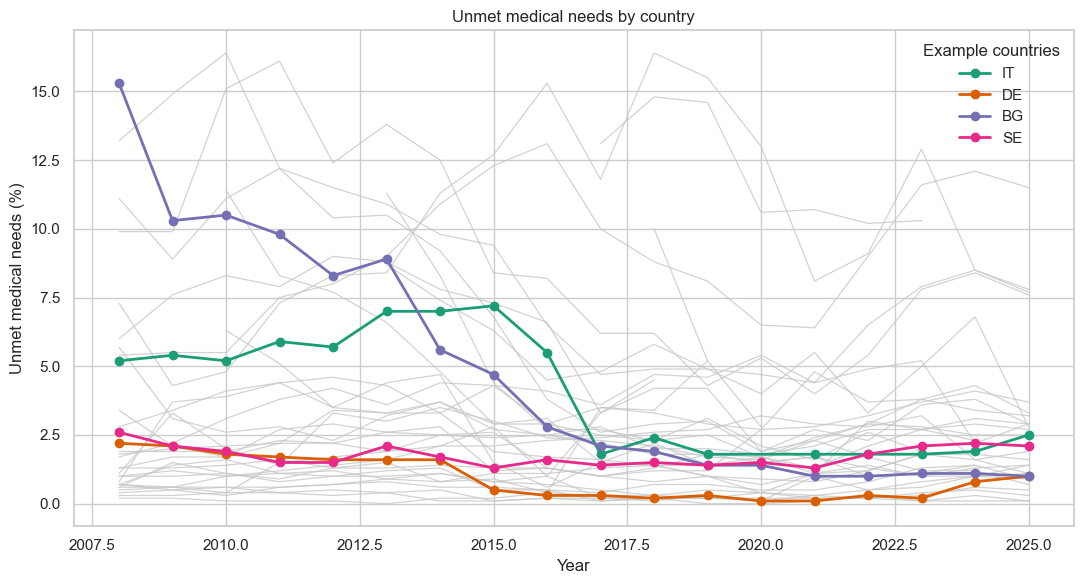

In [5]:
highlight_countries = ['IT', 'DE', 'BG', 'SE']
fig, ax = plt.subplots(figsize=(11, 6))

# draw all country paths in the background
for geo, group in panel.sort_values('year').groupby('geo'):
    ax.plot(group['year'], group['unmet_need_pc'], color='0.78', linewidth=0.9, alpha=0.8)

colors = {'IT': '#1b9e77', 'DE': '#d95f02', 'BG': '#7570b3', 'SE': '#e7298a'}
for geo in highlight_countries:
    group = panel.loc[panel['geo'].eq(geo)].sort_values('year')
    if group.empty:
        continue
    ax.plot(group['year'], group['unmet_need_pc'], marker='o', linewidth=2.0, label=geo, color=colors[geo])

ax.set_xlabel('Year')
ax.set_ylabel('Unmet medical needs (%)')
ax.set_title('Unmet medical needs by country')
ax.legend(title='Example countries', frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'unmet_need_trends_all_countries.png', dpi=180)
plt.show()

## Cross-section patterns

In [6]:
coverage_by_year = panel.groupby('year')['geo'].nunique().sort_index()
recent_year = int(coverage_by_year[coverage_by_year >= 20].index.max())
recent = panel.loc[panel['year'].eq(recent_year)].copy()
pd.DataFrame({'selected_year': [recent_year], 'countries': [recent['geo'].nunique()]})

,selected_year,countries
0,2025,30


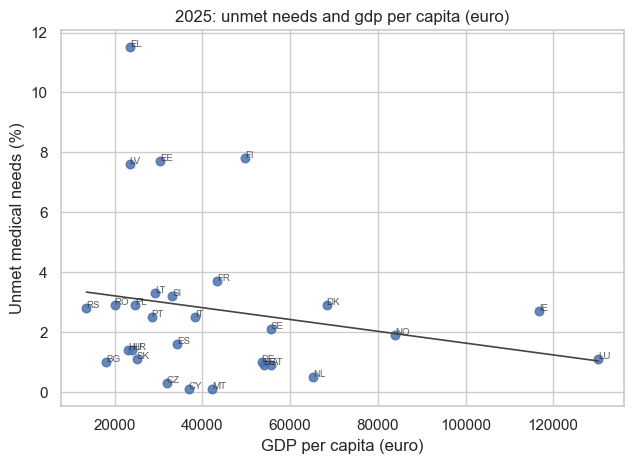

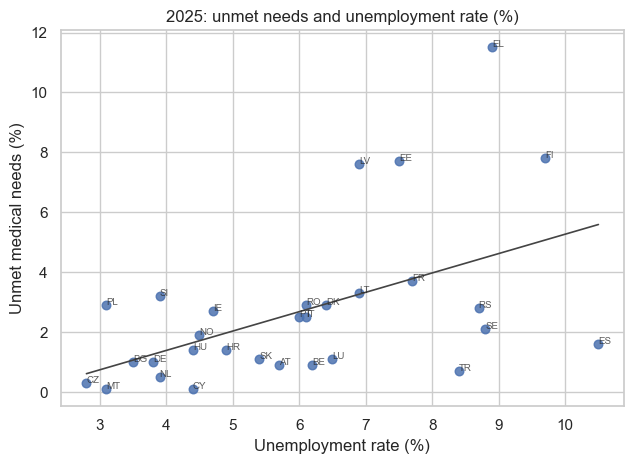

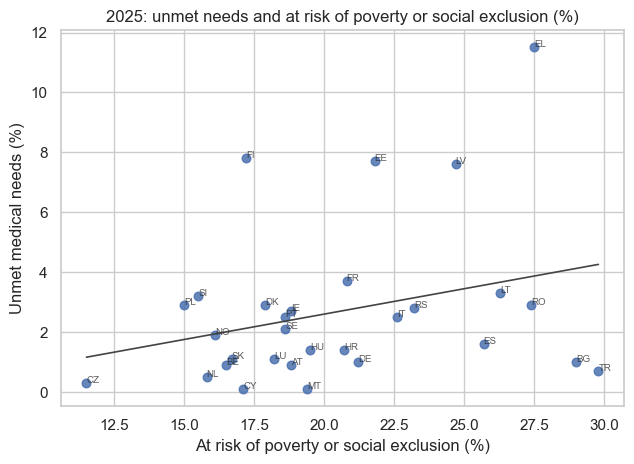

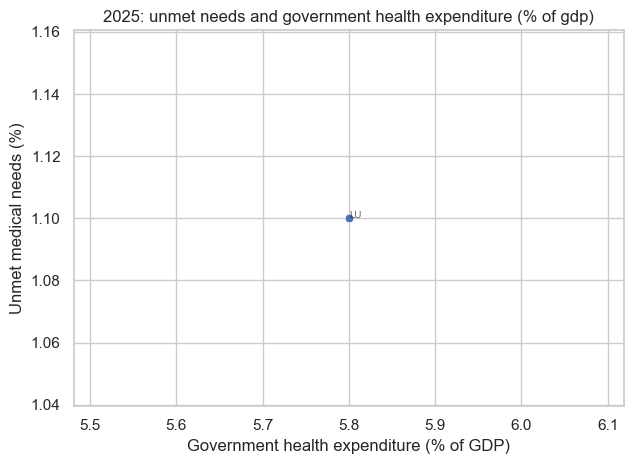

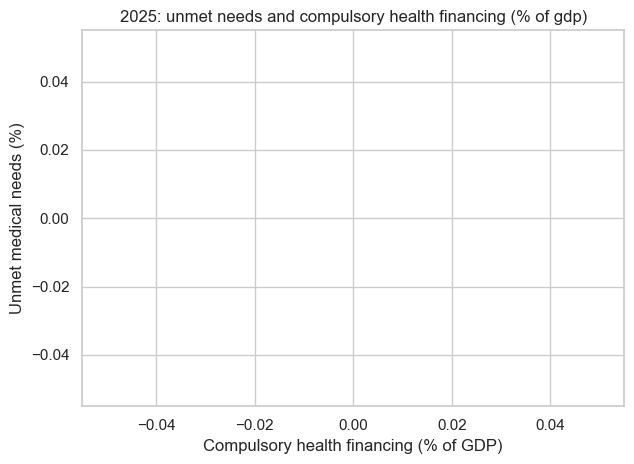

['outputs\\figures\\unmet_need_vs_gdp_per_capita_eur_2025.png',
 'outputs\\figures\\unmet_need_vs_unemployment_rate_pc_2025.png',
 'outputs\\figures\\unmet_need_vs_poverty_or_social_exclusion_pc_2025.png',
 'outputs\\figures\\unmet_need_vs_government_health_expenditure_gdp_pc_2025.png',
 'outputs\\figures\\unmet_need_vs_compulsory_health_financing_gdp_pc_2025.png']

In [7]:
axis_labels = {
    'gdp_per_capita_eur': 'GDP per capita (euro)',
    'unemployment_rate_pc': 'Unemployment rate (%)',
    'poverty_or_social_exclusion_pc': 'At risk of poverty or social exclusion (%)',
    'government_health_expenditure_gdp_pc': 'Government health expenditure (% of GDP)',
    'compulsory_health_financing_gdp_pc': 'Compulsory health financing (% of GDP)',
}

scatter_outputs = []
for control in approved_controls:
    plot_data = recent[['geo', 'unmet_need_pc', control]].dropna()
    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    if len(plot_data) >= 3:
        sns.regplot(
            data=plot_data,
            x=control,
            y='unmet_need_pc',
            ci=None,
            scatter_kws={'s': 38, 'alpha': 0.85},
            line_kws={'color': '#444444', 'linewidth': 1.2},
            ax=ax,
        )
    else:
        sns.scatterplot(data=plot_data, x=control, y='unmet_need_pc', s=38, ax=ax)
    for _, row in plot_data.iterrows():
        ax.text(row[control], row['unmet_need_pc'], row['geo'], fontsize=7, alpha=0.75)
    ax.set_xlabel(axis_labels[control])
    ax.set_ylabel('Unmet medical needs (%)')
    ax.set_title(f'{recent_year}: unmet needs and {axis_labels[control].lower()}')
    fig.tight_layout()
    output_path = FIGURES_DIR / f'unmet_need_vs_{control}_{recent_year}.png'
    fig.savefig(output_path, dpi=180)
    scatter_outputs.append(str(output_path.relative_to(PROJECT_ROOT)))
    plt.show()

scatter_outputs

## Correlations and distributions

In [8]:
correlation_vars = ['unmet_need_pc'] + approved_controls
complete_rows = panel[correlation_vars].dropna()
correlations = complete_rows.corr(method='pearson')
correlations.to_csv(PROJECT_ROOT / 'outputs' / 'panel_correlations.csv')
pd.DataFrame({'complete_rows': [len(complete_rows)]})

,complete_rows
0,282


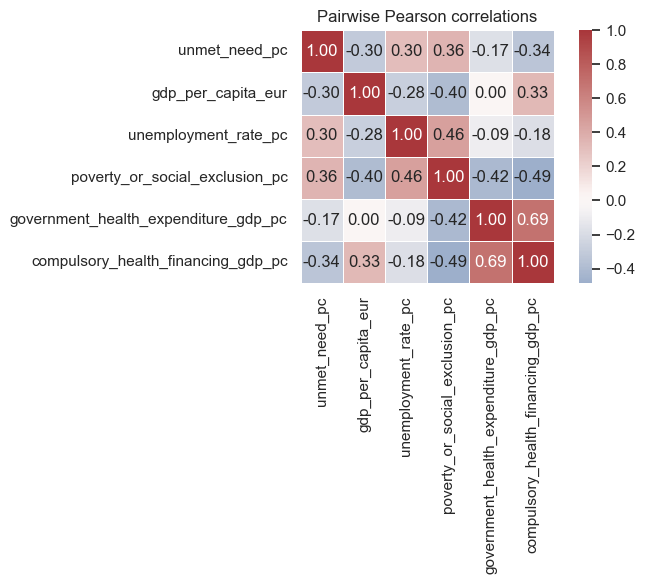

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    correlations,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    center=0,
    square=True,
    linewidths=0.4,
    ax=ax,
)
ax.set_title('Pairwise Pearson correlations')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'panel_correlations_heatmap.png', dpi=180)
plt.show()

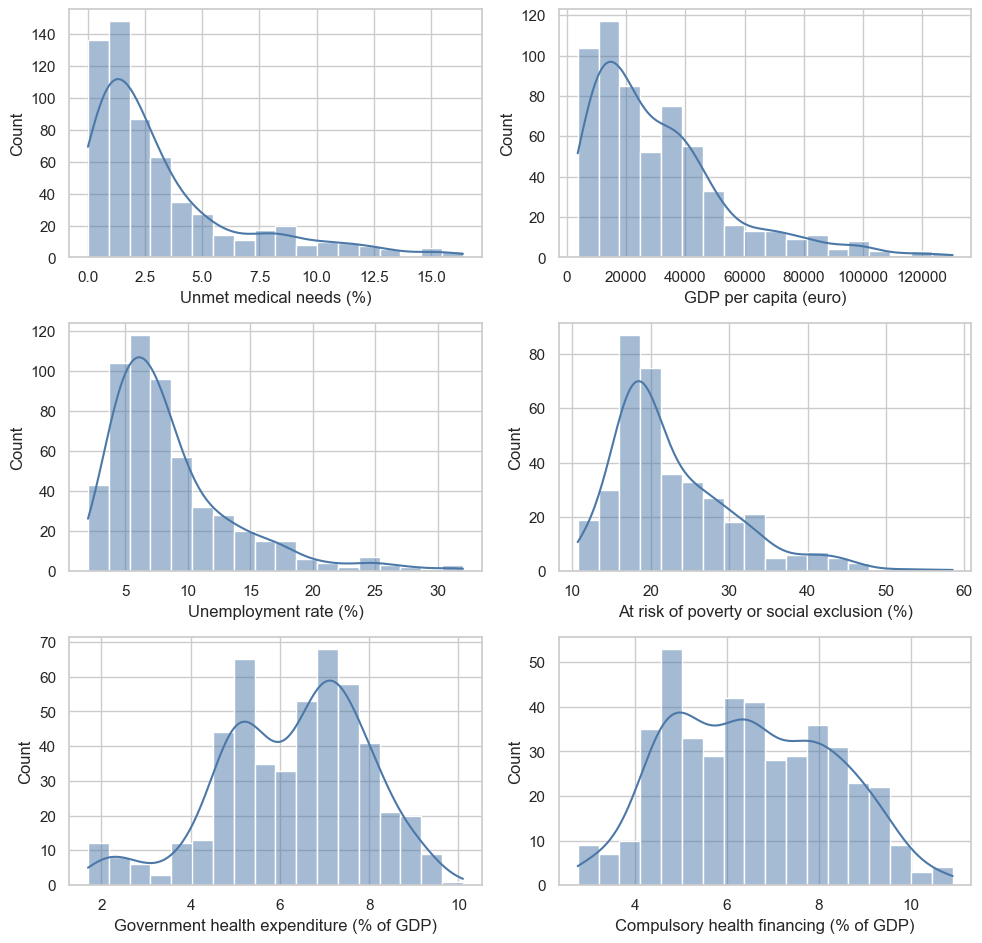

In [10]:
distribution_vars = correlation_vars
n_cols = 2
n_rows = int(np.ceil(len(distribution_vars) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.2 * n_rows))
axes = axes.flatten()
for ax, column in zip(axes, distribution_vars):
    sns.histplot(panel[column].dropna(), bins=18, kde=True, ax=ax, color='#4c78a8')
    ax.set_xlabel(axis_labels.get(column, 'Unmet medical needs (%)'))
    ax.set_ylabel('Count')
for ax in axes[len(distribution_vars):]:
    ax.set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'panel_variable_distributions.png', dpi=180)
plt.show()